#Analyzing and Predicting Used Car Prices Across Canada.
##Author- Dharmrajsinh Gohil
##Introduction:

In this project I am going to go through the basis of data science to analyze a used cars data set and use regression models to predict prices and compare them to find a good deal and where you could find a car with better pricing. I am using data called *ca-dealers-used.csv* from [this site](https://www.kaggle.com/datasets/rupeshraundal/marketcheck-automotive-data-us-canada). Although I renamed the file to *used_cars_canada.csv*  and uploaded the file to this project. I made a dataframe `cars` to store the data. For relatability I changed the name of the *state* column to *province*, as Canada doesn't have states.

In [1]:
# Run this cell to set up your notebook; no further action is needed.
import seaborn as sns
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

cars = pd.read_csv('/used_cars_canada.csv')
cars.rename(columns={"state": "province"}, inplace=True)
cars.head(5)

/tmp/ipykernel_8722/2422849607.py:14: DtypeWarning: Columns (13,15) have mixed types. Specify dtype option on import or set low_memory=False.
  cars = pd.read_csv('/used_cars_canada.csv')


,id,vin,price,miles,stock_no,year,make,model,trim,body_type,...,drivetrain,transmission,fuel_type,engine_size,engine_block,seller_name,street,city,province,zip
0,b39ea795-eca9,19UNC1B01HY800062,179999.0,9966.0,V-P4139,2017.0,Acura,NSX,Base,Coupe,...,4WD,Automatic,Electric / Premium Unleaded,3.5,V,edmundston honda,475 Rue Victoria,Edmundston,NB,E3V 2K7
1,026cb5b1-6e3e,19UNC1B02HY800023,179995.0,5988.0,PPAP70374,2017.0,Acura,NSX,Base,Coupe,...,4WD,Automatic,Electric / Premium Unleaded,3.5,V,garage daniel lessard,2795 Route-du-prsident-kennedy,Notre-dame-des-pins,QC,G0M 1K0
2,5cd5d5b2-5cc2,19UNC1B02HY800071,168528.0,24242.0,B21085,2017.0,Acura,NSX,Base,Coupe,...,4WD,Automatic,Electric / Premium Unleaded,3.5,V,lougheed acura,1388 Lougheed Highway,Coquitlam,BC,V3K 6S4
3,b32473ed-5922,19UNC1B02LY800001,220000.0,6637.0,AP5333,2020.0,Acura,NSX,Base,Coupe,...,4WD,Automatic,Electric / Premium Unleaded,3.5,V,drive autogroup,1305 Parkway Suite 600,Pickering,ON,L1V 3P2
4,ac40c9fc-0676,19UNC1B02LY800001,220000.0,6637.0,AP5333,2020.0,Acura,NSX,Base,Coupe,...,4WD,Automatic,Electric / Premium Unleaded,3.5,V,acura pickering,575 Kingston Road,Pickering,ON,L1V 3N7


Since we have a huge data set let see how many columns we have and among them how many null values there are.

In [2]:
cars.isna().sum()

,0
id,0
vin,0
price,35117
miles,27013
stock_no,27693
year,17
make,0
model,4794
trim,38779
body_type,34025


It seems there are a lot of columns with null values. One good thing is that we do not need all of them. For analysis I am only considering these columns:

* price,
* miles,
* year,
* make,
* body_type and
* province.

I am using these columns as they are primary indicators of price of a car for drivers. The information such as transmission type and engine size may matter to some people but ideally thats subjective.

In [3]:
keep_cols = ['price', 'miles', 'year', 'make', 'body_type', 'province']

cars = cars[keep_cols]
cars.isna().sum()

,0
price,35117
miles,27013
year,17
make,0
body_type,34025
province,7836


Even among these columns we have many empty values. To have a proper data set I have cleaned the data as follow:


*   For `'price'` I dropped the values as it is our response variable and predicting empty values wouldn't be wise.
*   For `'miles'` I substituted empty values with median of the all the miles as it is a good estimate for sample data and removing empty values will not give us accurate results.
*   For `'year'` I dropped the values as subsituting the values
will give false prediction.
*   For `'body_type'` I dropped the values to avoid false data representation.
*   For `'province'` I substituted values to `UNKNOWN` as it may end up useful indicator of where to buy cars from and to prevent information loss.

In [4]:
#drop rows with empty values in cols: price, year, model and body_type
cars = cars[cars['price'].notna() & cars['year'].notna()\
            & cars['body_type'].notna()]

#subsitute empty values for miles to median of miles
cars['miles'] = cars['miles'].fillna(cars['miles'].median())
#subsitute empty values for province to "UNKWON"
cars['province'] = cars['province'].fillna("UNKOWN")

cars.isna().sum()

,0
price,0
miles,0
year,0
make,0
body_type,0
province,0


Great! All the columns have no empty values which is perfect for analysis. Now I am just checking that all our categorical data is unique.

In [5]:
make = cars['make'].value_counts().index
body_type = cars['body_type'].value_counts().index
province = cars['province'].value_counts().index

print(f"""Does make column have all different values: {make.is_unique}\n
Does body type column have all different values: {body_type.is_unique}\n
Does province column have all different values: {province.is_unique}\n""")

Does make column have all different values: True

Does body type column have all different values: True

Does province column have all different values: True



You may think the data is clean and ready to process but, there are few values in province which are not in Canada. In addition some cars that are comercial or unconventional daily commutes are also present.

In [6]:
province.sort_values()

Index(['AB', 'BC', 'MB', 'NB', 'NC', 'NL', 'NS', 'NT', 'OH', 'ON', 'PE', 'QC',
       'SC', 'SK', 'UNKOWN', 'YT'],
      dtype='object', name='province')

In [7]:
body_type

Index(['SUV', 'Sedan', 'Hatchback', 'Pickup', 'Minivan', 'Coupe', 'Wagon',
       'Convertible', 'Cargo Van', 'Mini Mpv', 'Passenger Van', 'Micro Car',
       'Cutaway', 'Targa', 'Van', 'Chassis Cab', 'Crossover', 'Car Van',
       'Combi', 'Roadster', 'Commercial Wagon'],
      dtype='object', name='body_type')

I removed the values: *OH* - Ohio, *NC* - North Carolina and *SC* - South Carolina from province columns as these are not present in Canada.

And removed the body_type: *Cargo Van*, *Passenger Van*, *Cutaway*, *Chassis Cab*, *Commercial Wagon* and *Combi*. These are the unconventional cars which are not for daily commutes or for a regular person looking for a new car.

I also merged some values in one to generalize them. I merged them as follow:

* *Hatchback*, *Micro Car*, *Mini Mpv* and *Crossover* to *Hatchback*.
* *Coupe*, *Convertible*, *Targa* and *Roadster* to *Coupe*.
* *Minivan*, *Wagon*, *Van* and *Car Van* to *Family Car*.

In [8]:
cars = cars[~cars['province'].isin(["OH","NC","SC"])]
cars = cars[~cars['body_type'].isin(['Cargo Van', 'Passenger Van', 'Cutaway', 'Chassis Cab', 'Commercial Wagon','Combi'])]

cars['body_type'] = (cars['body_type']
                     .replace(["Micro Car", "Mini Mpv", "Crossover"],"Hatchback"))
cars['body_type'] = (cars['body_type']
                     .replace(["Convertible", "Targa", "Roadster"],"Coupe"))
cars['body_type'] = (cars['body_type']
                     .replace(["Minivan", "Wagon", "Van", "Car Van"],"Family Car"))

print("After clearing:")
print(cars['province'].value_counts().index.sort_values())
print(cars['body_type'].value_counts().index)

After clearing:
Index(['AB', 'BC', 'MB', 'NB', 'NL', 'NS', 'NT', 'ON', 'PE', 'QC', 'SK',
       'UNKOWN', 'YT'],
      dtype='object', name='province')
Index(['SUV', 'Sedan', 'Hatchback', 'Pickup', 'Family Car', 'Coupe'], dtype='object', name='body_type')


Lets have a look at much cleaner and final dataset to work on.



In [9]:
cars.sample(5)

,price,miles,year,make,body_type,province
294047,14995.0,54349.0,2015.0,Kia,Coupe,QC
162759,5485.0,238846.0,2008.0,Toyota,Sedan,ON
350971,37995.0,102595.0,2016.0,BMW,SUV,SK
253069,19999.0,72699.0,2018.0,Mitsubishi,SUV,AB
353465,46966.0,14000.0,2020.0,Volvo,Sedan,NS


To answer one of the questions, what province has the best deals in the country, this graph should provide some insight. Here I plot a graph which shows the average price of a car in each province.

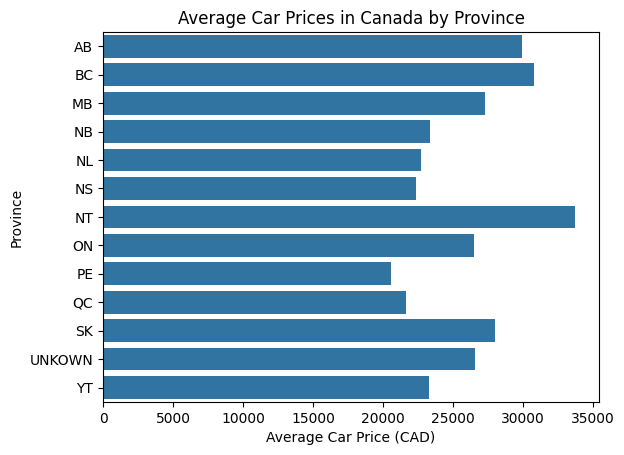

In [10]:
#group by province and show the average price of a car
mean_price_by_province = cars.groupby('province')['price'].mean()

sns.barplot(x=mean_price_by_province, y=mean_price_by_province.index)
plt.title("Average Car Prices in Canada by Province")
plt.xlabel("Average Car Price (CAD)")
plt.ylabel("Province")
plt.show()

In [11]:
print(mean_price_by_province[mean_price_by_province == mean_price_by_province.min()])

province
PE    20545.050372
Name: price, dtype: float64


According to the graph above we see that Prince Edward Island has the lowest on-average prices around $20,500. Meaning statistically this province has better on-average prices of cars. Though it could be because there are not many expensive cars here, such as luxary cars. Lets see what are the most expensive and the cheapest cars brands:

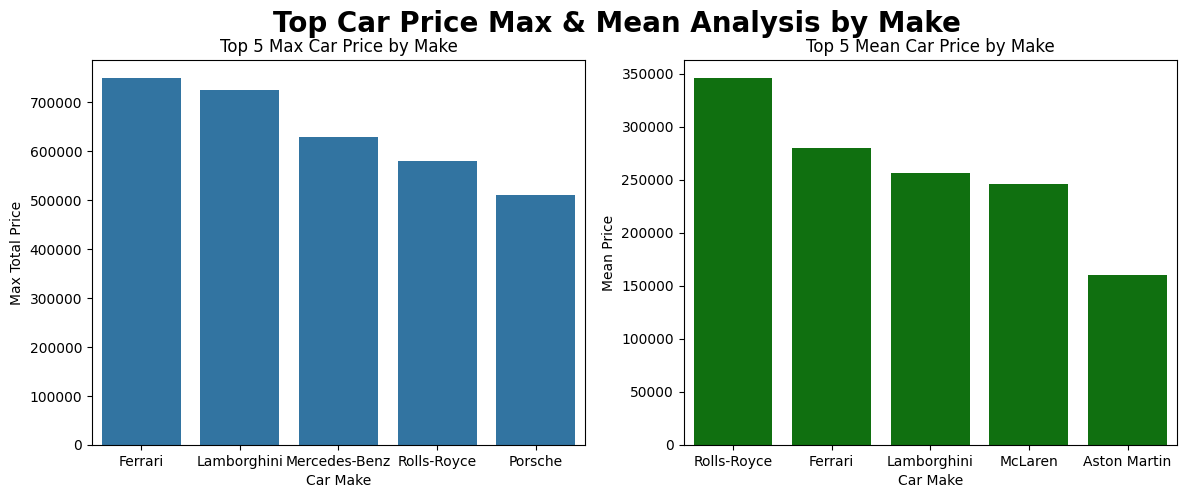

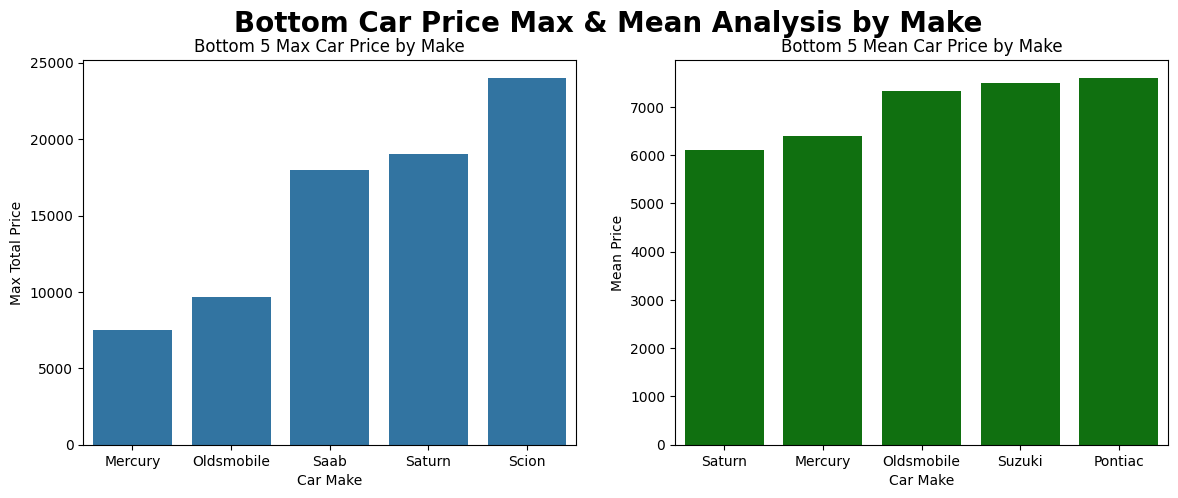

In [12]:
#top and bottom 10 car brands by total price
top_max_price_by_make = cars.groupby('make')['price'].max().sort_values(ascending=False)[:5]
bottom_max_price_by_make = cars.groupby('make')['price'].max().sort_values()[:5]

#top and bottom 10 car brands by mean price
top_mean_price_by_make = cars.groupby('make')['price'].mean().sort_values(ascending=False)[:5]
bottom_mean_price_by_make = cars.groupby('make')['price'].mean().sort_values()[:5]

#show the plots in 2x2 grid first total price and then mean prices

fig1, axes = plt.subplots(1, 2,figsize=(14, 5))

sns.barplot(x=top_max_price_by_make.index, y=top_max_price_by_make, ax=axes[0])
axes[0].set_title("Top 5 Max Car Price by Make")
axes[0].set_xlabel("Car Make")
axes[0].set_ylabel("Max Total Price")

sns.barplot(x=top_mean_price_by_make.index, y=top_mean_price_by_make, ax=axes[1], color="green")
axes[1].set_title("Top 5 Mean Car Price by Make")
axes[1].set_xlabel("Car Make")
axes[1].set_ylabel("Mean Price")
fig1.suptitle("Top Car Price Max & Mean Analysis by Make", fontsize=20, fontweight='bold')
plt.show()

fig2, axes = plt.subplots(1, 2,figsize=(14, 5))

sns.barplot(x=bottom_max_price_by_make.index, y=bottom_max_price_by_make, ax=axes[0])
axes[0].set_title("Bottom 5 Max Car Price by Make")
axes[0].set_xlabel("Car Make")
axes[0].set_ylabel("Max Total Price")

sns.barplot(x=bottom_mean_price_by_make.index, y=bottom_mean_price_by_make, ax=axes[1], color="green")
axes[1].set_title("Bottom 5 Mean Car Price by Make")
axes[1].set_xlabel("Car Make")
axes[1].set_ylabel("Mean Price")
fig2.suptitle("Bottom Car Price Max & Mean Analysis by Make", fontsize=20, fontweight='bold')
plt.show()

Here, the graph shows the top 5 car brands by only price are: Ferrari, Lamborghini, Mercedes-Benz, Rolls Royce and Porche. Among these 3 have top average prices as well. That shows that they are one of the most expensives cars to buy in Canada. The other graph shows the cheapest options too. Brands like Mercury, Satrun and Oldsmobile have the cheapest car prices to buy in Canada. But is that the only factor the price?

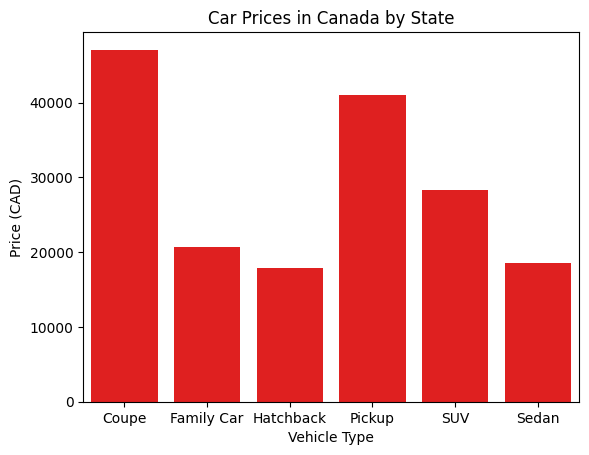

In [13]:
mean_price_by_body_type = cars.groupby('body_type')['price'].mean()

sns.barplot(x=mean_price_by_body_type.index, y=mean_price_by_body_type, color="red")
plt.title("Car Prices in Canada by State")
plt.xlabel("Vehicle Type")
plt.ylabel("Price (CAD)")
plt.show()

It seems no. The body type of the vehicle is also a major factor for prices. On average hatchbacks are the cheapest while coupes are the most expensive which is understandable. Since most sports cars and luxary cars tend to come in coupes they are pretty expensive. Then comes the big cars like pick-up truck and SUVs. And the trend continues that the size of car or rather the body type contributes to its price.

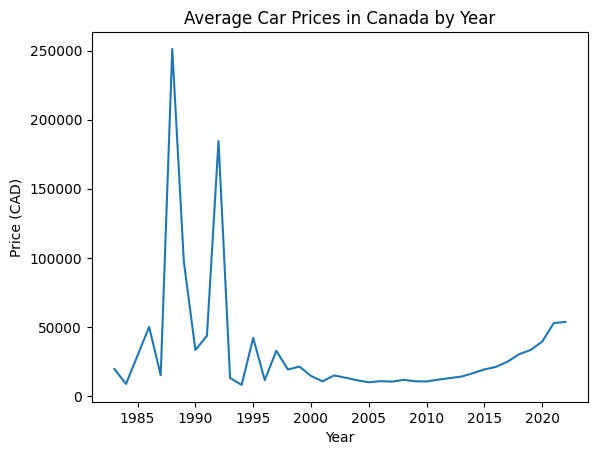

In [14]:
#group by year and price and show line graph
mean_price_by_year = cars.groupby('year')['price'].mean().sort_index()

plt.plot(mean_price_by_year.index,mean_price_by_year)
plt.title("Average Car Prices in Canada by Year")
plt.xlabel("Year")
plt.ylabel("Price (CAD)")
plt.show()

The age of the car is also determines its value. Idealy newer cars are more expensive however, in the graph there's two big spike between 1985 to 1995. This indicates that cars in this years are more expensive, could be because of vintage car prices or we have more cars from these years.

Now lets see probably the most important factor miles driven:

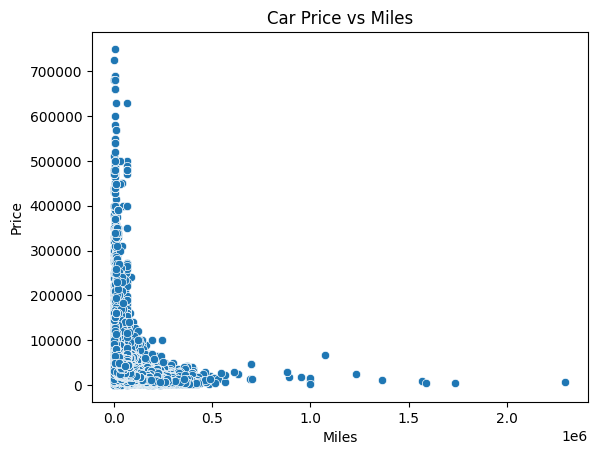

In [15]:
sns.scatterplot(x='miles', y='price', data=cars)
plt.title("Car Price vs Miles")
plt.xlabel("Miles")
plt.ylabel("Price")
plt.show()

We have a lots of cars with not driven a lot. Most of the cars are within 0-50k miles and some are aound 200k miles driven. I am transforming the data to better visualize. Here I have get the square root of miles and had log function to strech and squeeze it, I am using `log1p()` to avoid `$∞$` or null values during calculations. For prices I am only taking square root to squeeze the data.

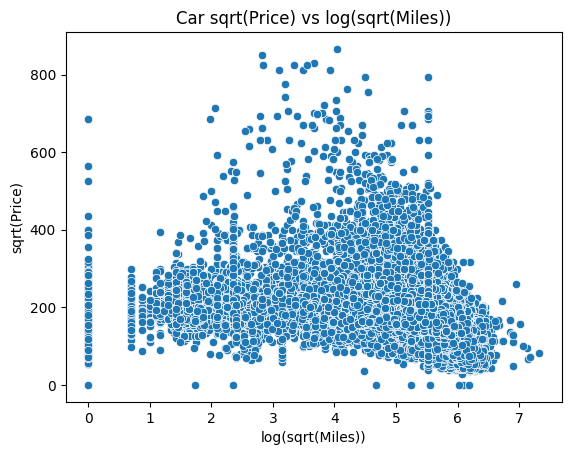

In [16]:
cars['transformed_miles'] = np.log1p(np.sqrt(cars['miles']))

cars['sqrt_price'] = np.sqrt(cars['price'])

sns.scatterplot(x='transformed_miles', y='sqrt_price', data = cars)
plt.title("Car sqrt(Price) vs log(sqrt(Miles))")
plt.xlabel("log(sqrt(Miles))")
plt.ylabel("sqrt(Price)")
plt.show()

This is better although as expected there are a lot of data points condensed at some points to see where the next graph will be benefical.

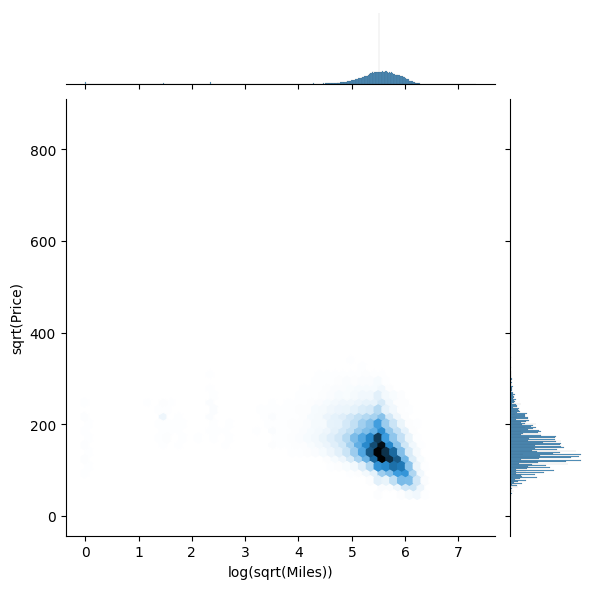

In [17]:
sns.jointplot(x='transformed_miles', y='sqrt_price', data= cars, kind="hex")
plt.xlabel("log(sqrt(Miles))")
plt.ylabel("sqrt(Price)")
plt.show()

Since the datapoints are heavily clusted at around 5.5 on x-axis most of the cars in the data has milage: $(e^{5.5})^2 \approx 60,000$ miles and the price is around $40,000.

I took a small sample of the data and it shows similar results as the graph above.

<Axes: xlabel='transformed_miles', ylabel='sqrt_price'>

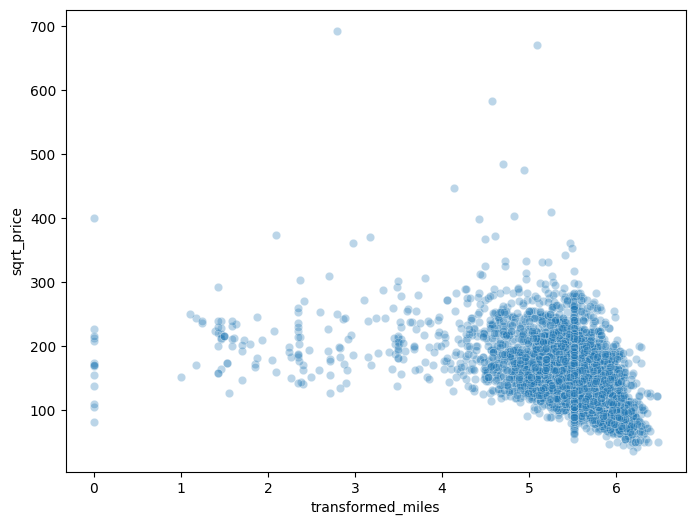

In [18]:
sample_cars = cars.sample(5000)

plt.figure(figsize=(8,6))
sns.scatterplot(x='transformed_miles', y='sqrt_price', data=sample_cars, alpha=0.3)

Now that I have the idea on how different factors are affecting the car prices lets predict the values using them.

For prediction I made a new data frame named `train_cars`, in it I have
* *prices*,
* *miles*,
* *car_age* - how old the car is compared to the most recent car in the data
* *body_type*
* *province*
* *make*

Here I did some feature engineering like target encoding on make to update the categorical value to mean numerical value by their brands, one-hot-encoding on body_type and province.

In [19]:
#make a new data fram which has transformed values along with one-hot-encoded, target encoded and numeric data
#for computation

train_cars = pd.DataFrame()

#data frame with transformed values
train_cars['miles'] = cars['transformed_miles']
train_cars['price'] = cars['sqrt_price']
train_cars['car_age'] = cars['year'].max() - cars['year']
train_cars['province'] = cars['province']
train_cars['body_type'] = cars['body_type']
train_cars['make'] = cars['make']
#data frame with one-hot-encoded values
ohe = OneHotEncoder()

#for province:
ohe.fit(train_cars[['province']])
encoded_province = ohe.transform(train_cars[['province']]).toarray()
encoded_province_df = pd.DataFrame(encoded_province, columns=ohe.get_feature_names_out(), index=train_cars.index)
train_cars = train_cars.join(encoded_province_df)
train_cars = train_cars.drop(columns=['province'])

#for body_type:
ohe.fit(train_cars[['body_type']])
encoded_body_type = ohe.transform(train_cars[['body_type']]).toarray()
encoded_body_type_df = pd.DataFrame(encoded_body_type, columns=ohe.get_feature_names_out(), index=train_cars.index)
train_cars = train_cars.join(encoded_body_type_df)
train_cars = train_cars.drop(columns=['body_type'])

#target encoding: update the values of make with average prices of each make
mean_price_by_make = cars.groupby('make')['price'].mean()
train_cars['avg_make_price'] = train_cars['make'].map(mean_price_by_make)
train_cars = train_cars.drop(columns=['make'])

print(train_cars.isna().sum())
train_cars.sample(5)

miles                   0
price                   0
car_age                 0
province_AB             0
province_BC             0
province_MB             0
province_NB             0
province_NL             0
province_NS             0
province_NT             0
province_ON             0
province_PE             0
province_QC             0
province_SK             0
province_UNKOWN         0
province_YT             0
body_type_Coupe         0
body_type_Family Car    0
body_type_Hatchback     0
body_type_Pickup        0
body_type_SUV           0
body_type_Sedan         0
avg_make_price          0
dtype: int64


,miles,price,car_age,province_AB,province_BC,province_MB,province_NB,province_NL,province_NS,province_NT,...,province_SK,province_UNKOWN,province_YT,body_type_Coupe,body_type_Family Car,body_type_Hatchback,body_type_Pickup,body_type_SUV,body_type_Sedan,avg_make_price
259424,5.300323,143.481706,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,19447.225366
89846,5.674412,133.341666,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,33522.382578
363201,5.460194,304.775327,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,58319.773890
379472,5.674761,173.170436,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,42997.350362
162187,5.500329,187.069506,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,33599.421408


The data set is ready for prediction. I plan on using linear regression to predict price values, here the loss function I have is L2 or Mean Squared Error: $\frac{1}{n}\sum (y-\hat{y})^2$.

I made multiple models:
* one Linear Regression model with just miles as a feature to predict price,
* one Linear Regression model with all the features to predict price and,
* one Gradient Descent modcel with all the features to predict the price.


Linear Regression model with just miles:

In [20]:
SLR1 = LinearRegression()
SLR1.fit(train_cars[['miles']], train_cars['price'])

LinearRegression()

In [21]:
train_cars['predicted_price1'] = SLR1.predict(train_cars[['miles']])

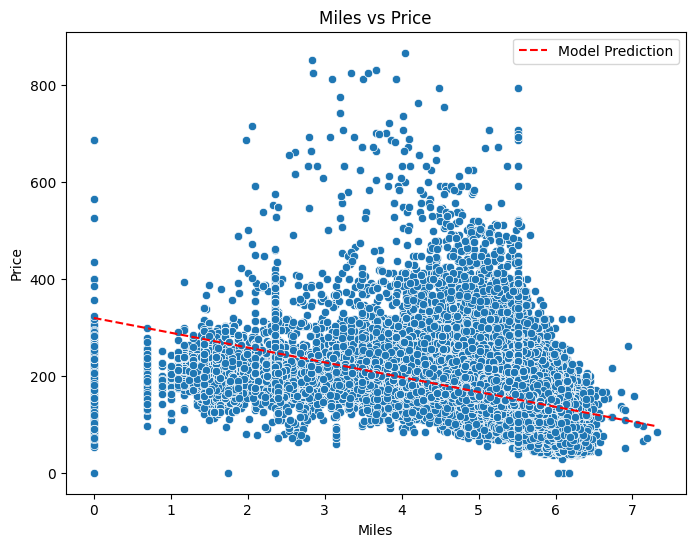

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='miles', y='price', data=train_cars)

# Sort values for clean line
sorted_car_by_miles = train_cars.sort_values(by='miles')

plt.plot(sorted_car_by_miles['miles'],
         sorted_car_by_miles['predicted_price1'],
         color='red', linestyle='--', label='Model Prediction')

plt.title("Miles vs Price")
plt.xlabel("Miles")
plt.ylabel("Price")
plt.legend()

plt.show()

As seen in the above graph there the best fit line pretty much divides the plot into 2 segments with data points above the line as more expensive than their worth and data points below the line as good prices or better deals.

Linear Regression with all features:

In [23]:
features = train_cars.columns[~train_cars.columns.isin(['predicted_price1','price'])]

SLR2 = LinearRegression()
SLR2.fit(train_cars[features], train_cars['price'])

LinearRegression()

In [24]:
train_cars['predicted_price2'] = SLR2.predict(train_cars[SLR2.feature_names_in_])

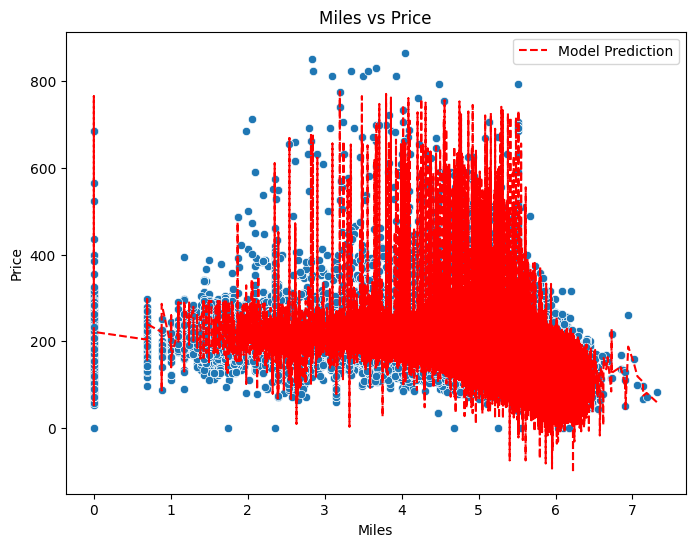

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='miles', y='price', data=train_cars)

# Sort values for clean line
sorted_car_by_miles = train_cars.sort_values(by='miles')

plt.plot(sorted_car_by_miles['miles'],
         sorted_car_by_miles['predicted_price2'],
         color='red', linestyle='--', label='Model Prediction')

plt.title("Miles vs Price")
plt.xlabel("Miles")
plt.ylabel("Price")
plt.legend()

plt.show()

Here the best fit line is cluttery go=ing all over the place. Let's refine it so it gives a better visual. I am getting rid of the outliers. In the plot most of the points are with 4 and 7 on the x-axis and between 0-450 on the y-axis.

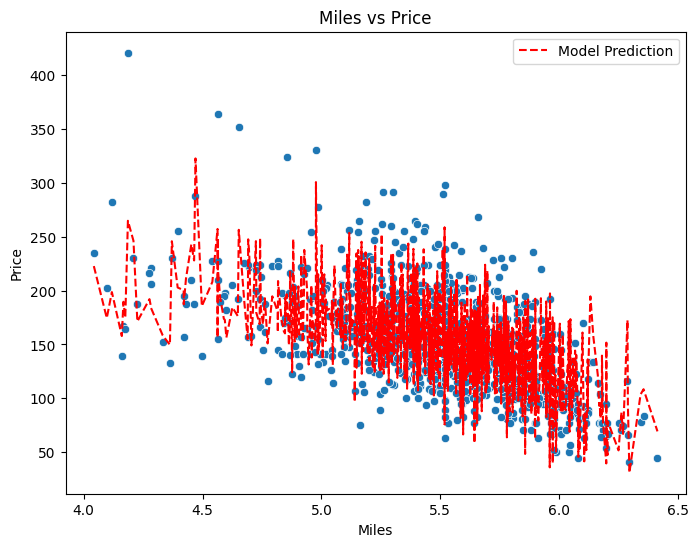

In [26]:
#sample_train_cars = train_cars.sample(1000)
sample_train_cars = train_cars[(train_cars['miles']>=4) & (train_cars['price'] <= 450)].sample(1000)

plt.figure(figsize=(8,6))
sns.scatterplot(x='miles', y='price', data=sample_train_cars)

# Sort values for clean line
sorted_car_by_miles = sample_train_cars.sort_values(by='miles')

plt.plot(sorted_car_by_miles['miles'],
         sorted_car_by_miles['predicted_price2'],
         color='red', linestyle='--', label='Model Prediction')

plt.title("Miles vs Price")
plt.xlabel("Miles")
plt.ylabel("Price")
plt.legend()

plt.show()

It is a lot better now but still the best fit line does look like the model is overfitting. We need one more model to compare the results.

That's why we also check the last model, Gradient Descent:

The following are the methods created for gradient descent. Again I am choosing L2 loss here.

In [27]:
#make loss function:

def grad_loss_func(residual, X):

  return (X.T @ residual)/len(residual)


In [28]:
#mse loss function:

def mse_loss_func(residual):

  return np.mean(residual**2)

In [29]:
def grad_desc_predict(theta, X):
  return X @ theta

In [30]:
def grad_desc(X, Y, grad_y_pred, mse_loss, grad_loss, alpha, steps):

  theta = np.zeros(X.shape[1])
  loss_history = []

  for i in range(steps):

    Y_pred = grad_y_pred(theta, X)
    residual = Y_pred - Y

    loss_history.append(mse_loss(residual))
    theta = theta - alpha*(grad_loss(residual, X))


  return theta, loss_history

In [31]:
# Get X and Y for gradient descent:
X = train_cars[features]
Y = train_cars['price']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)

theta_hat, losses_calculated = grad_desc(X, Y, grad_desc_predict, mse_loss_func, grad_loss_func, 0.1, 200)

for l in losses_calculated:
    print(f"Loss: {l}")

Loss: 26165.827493792858
Loss: 21178.211076734773
Loss: 17184.695391722584
Loss: 13982.08853749249
Loss: 11410.194046236775
Loss: 9342.293612120162
Loss: 7677.853555013627
Loss: 6336.904046589022
Loss: 5255.684655968976
Loss: 4383.254449239742
Loss: 3678.8411364772246
Loss: 3109.7596573098963
Loss: 2649.771827528422
Loss: 2277.789278811524
Loss: 1976.8447950797542
Loss: 1733.2743487289115
Loss: 1536.0651564300533
Loss: 1376.3349853066027
Loss: 1246.9155314185066
Loss: 1142.018539168185
Loss: 1056.9678569884616
Loss: 987.984146554954
Loss: 932.011715151895
Loss: 886.5791006602008
Loss: 849.6867397976548
Loss: 819.7163946175376
Loss: 795.3580778763971
Loss: 775.5510647746927
Loss: 759.4362532376954
Loss: 746.3176734867756
Loss: 735.631378391261
Loss: 726.9202911382115
Loss: 719.8138635504055
Loss: 714.0116206973757
Loss: 709.2698461955639
Loss: 705.3908064531993
Loss: 702.2140279890943
Loss: 699.6092353532122
Loss: 697.4706325067789
Loss: 695.7122713094909
Loss: 694.264299840768
Loss: 69

Let's check how well the model is doing.

Text(0, 0.5, 'Loss Error')

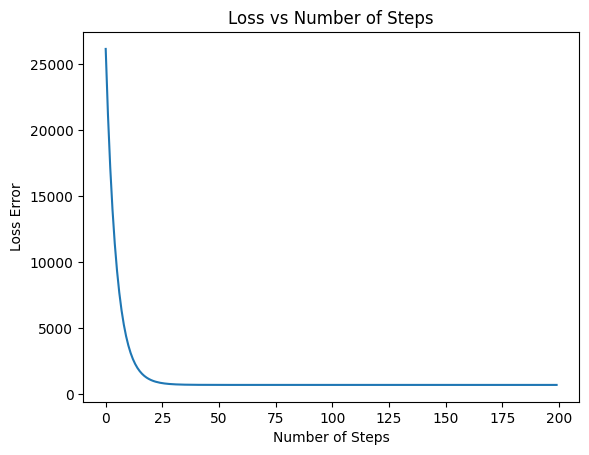

In [32]:
plt.plot(losses_calculated)
plt.title("Loss vs Number of Steps")
plt.xlabel("Number of Steps")
plt.ylabel("Loss Error")

Great! we the loss is decreasing as needed. But we reach a saturated point as the loss is super minimal after 25 steps. To keep it simple I am choosing 25 steps to calculate the $\theta$. This seem a good place as the loss is minimal and we are not over fitting the values.

In [33]:
#theta_used, losses_calculated = grad_desc(X, Y, grad_desc_predict, mse_loss_func, grad_loss_func, 0.1, 100)

In [34]:
train_cars['predicted_price3'] = grad_desc_predict(theta_hat, X)

Now to see which model is a better for our data lets compare the MSE values and $R^2$ values.

In [35]:
mse_SLR1 = mean_squared_error(train_cars['price'], train_cars['predicted_price1'])
mse_SLR2 = mean_squared_error(train_cars['price'], train_cars['predicted_price2'])
mse_Gradient_Descent = mean_squared_error(train_cars['price'], train_cars['predicted_price3'])

r2_SLR1 = r2_score(train_cars['price'], train_cars['predicted_price1'])
r2_SLR2 = r2_score(train_cars['price'], train_cars['predicted_price3'])
r2_Gradient_Descent = r2_score(train_cars['price'], train_cars['predicted_price3'])

print(f"""\tSLR1\t\tSLR2\t\tGrad_Desc\n
MSE\t{mse_SLR1:.3f}\t{mse_SLR2:.3f}\t\t{mse_Gradient_Descent:.3f}\n
R^2\t{r2_SLR1:.3f}\t\t{r2_SLR2:.3f}\t\t{r2_Gradient_Descent:.3f}""")

	SLR1		SLR2		Grad_Desc

MSE	1987.488	686.864		686.864

R^2	0.175		0.715		0.715


As we see above that the Linear Regression with just miles has a fairly okay Loss how ever one feature (miles) just shows 17.5% of the variation in the data.

Linear Regression model with all the feature does gives us a better variation as 71.5% with the minimum Loss.

Laslty the Gradient Descent model shows similar results as Linear Refression model with multiple features, unless we change our $\alpha$ oe number of steps.

Now instead of using the entire data I'll perform a train-test-split to compare if the model is overfitting, underfitting or gives same results. For this I am changing the $\alpha$ value for Gradient Descent to 0.01 and increasing number of steps to find the minima.

In [36]:
train_X, test_X, train_Y, test_Y = train_test_split(train_cars[features], train_cars['price'], test_size = 0.2, random_state = 42)

scaler = StandardScaler()
train_X_gd = scaler.fit_transform(train_X)
train_X_gd = np.concatenate((np.ones((train_X.shape[0], 1)), train_X_gd), axis=1)
test_X_gd = scaler.transform(test_X)
test_X_gd = np.concatenate((np.ones((test_X.shape[0], 1)), test_X_gd), axis=1)

SLR1.fit(train_X[['miles']], train_Y)
SLR2.fit(train_X, train_Y)
theta_hat1, losses_calculated_1 = grad_desc(train_X_gd, train_Y, grad_desc_predict, mse_loss_func, grad_loss_func, 0.01, 500)

train_predict_SLR1 = SLR1.predict(train_X[['miles']])
train_predict_SLR2 = SLR2.predict(train_X[SLR2.feature_names_in_])
train_predict_Gradient_Descent = grad_desc_predict(theta_hat1, train_X_gd)

test_predict_SLR1 = SLR1.predict(test_X[['miles']])
test_predict_SLR2 = SLR2.predict(test_X[SLR2.feature_names_in_])
test_predict_Gradient_Descent = grad_desc_predict(theta_hat1, test_X_gd)

In [37]:
mse_SLR1_train = mean_squared_error(train_Y, train_predict_SLR1)
mse_SLR2_train = mean_squared_error(train_Y, train_predict_SLR2)
mse_Gradient_Descent_train = mean_squared_error(train_Y, train_predict_Gradient_Descent)

r2_SLR1_train = r2_score(train_Y, train_predict_SLR1)
r2_SLR2_train = r2_score(train_Y, train_predict_SLR2)
r2_Gradient_Descent_train = r2_score(train_Y, train_predict_Gradient_Descent)

mse_SLR1_test = mean_squared_error(test_Y, test_predict_SLR1)
mse_SLR2_test = mean_squared_error(test_Y, test_predict_SLR2)
mse_Gradient_Descent_test = mean_squared_error(test_Y, test_predict_Gradient_Descent)

r2_SLR1_test = r2_score(test_Y, test_predict_SLR1)
r2_SLR2_test = r2_score(test_Y, test_predict_SLR2)
r2_Gradient_Descent_test = r2_score(test_Y, test_predict_Gradient_Descent)

print(f"""\t\tSLR1\t\tSLR2\t\tGrad_Desc\n
Train MSE\t{mse_SLR1_train:.3f}\t{mse_SLR2_train:.3f}\t\t{mse_Gradient_Descent_train:.3f}\n
Test MSE\t{mse_SLR1_test:.3f}\t{mse_SLR2_test:.3f}\t\t{mse_Gradient_Descent_test:.3f}\n
Train R^2\t{r2_SLR1_train:.3f}\t\t{r2_SLR2_train:.3f}\t\t{r2_Gradient_Descent_train:.3f}\n
Test R^2\t{r2_SLR1_test:.3f}\t\t{r2_SLR2_test:.3f}\t\t{r2_Gradient_Descent_test:.3f}""")

		SLR1		SLR2		Grad_Desc

Train MSE	1987.725	685.083		687.026

Test MSE	1986.572	694.048		696.084

Train R^2	0.174		0.715		0.715

Test R^2	0.179		0.713		0.712


By observing the reults above the Linear Regression Model from sklearn with multiple features is very similar to Gradient Descent model. Though the regression model performs slightly better and as such I am using that for prediction and to calculate for better deals.

I created another column *deal_score* which keeps track of how good the deal is compared to the predicted value. Basically it is residual of predicted prices from the chosen model and actual price of the cars.

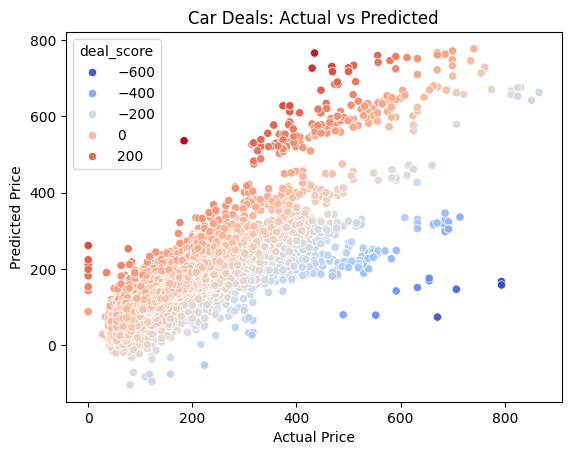

In [38]:
train_cars['deal_score'] = train_cars['predicted_price2'] - train_cars['price']

sns.scatterplot(x = train_cars['price'], y = train_cars['predicted_price2'], hue = train_cars['deal_score'], palette = 'coolwarm')

plt.title("Car Deals: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In the plot above all the *deal_score* values which are more than 0, are all red ameaning they are good deals.

Now I am making a data frame `good_deals` which will keep only good deals.

In [39]:
train_cars['province'] = cars.loc[train_cars.index, 'province']
good_deals = train_cars[train_cars['deal_score'] >= 0]
good_deals.head(5)

,miles,price,car_age,province_AB,province_BC,province_MB,province_NB,province_NL,province_NS,province_NT,...,body_type_Hatchback,body_type_Pickup,body_type_SUV,body_type_Sedan,avg_make_price,predicted_price1,predicted_price2,predicted_price3,deal_score,province
23,6.224749,38.729833,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,21468.980200,129.057640,55.549076,55.550090,16.819243,ON
24,5.517890,104.857046,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,19809.288136,150.646018,133.581954,133.582150,28.724909,ON
29,6.049931,113.995614,10.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,43789.938987,134.396793,167.610293,167.610729,53.614679,NB
30,5.876806,146.625373,10.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,43789.938987,139.684248,169.133123,169.133726,22.507750,NB
34,6.075481,141.024821,11.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,43789.938987,133.616471,171.768523,171.769155,30.743703,AB


Creating another dataframe `province_deals` which has total number of good deals by each province

In [40]:
province_deals = good_deals.groupby('province')['deal_score'].count()
province_deals

,deal_score
province,
AB,27169
BC,23033
MB,4812
NB,3007
NL,2184
NS,6021
NT,23
ON,57936
PE,679


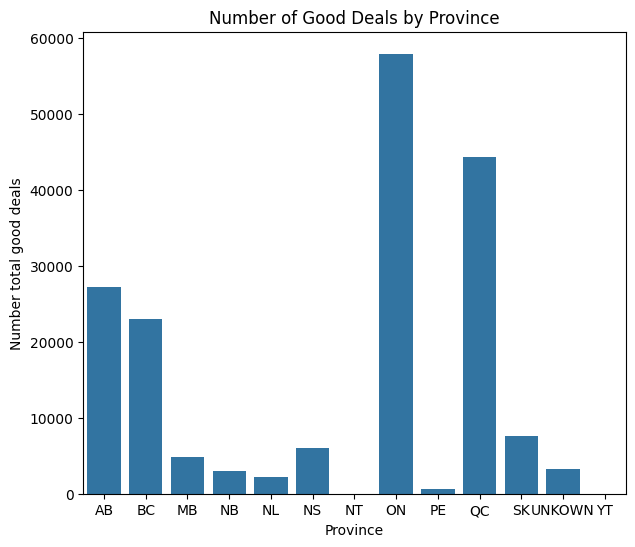

In [41]:
plt.figure(figsize = (7,6))
sns.barplot(x = province_deals.index, y = province_deals)
plt.title("Number of Good Deals by Province")
plt.xlabel("Province")
plt.ylabel("Number total good deals")
plt.show()

Finally we can see that to the best deals in Canada, Ontario has the most amount of good deals and thus getting a car from Ontario will end up giving better car price.

##End